In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive/TheNextDecade/Diabetes"

Mounted at /content/drive
BPXO_L.xpt
diabetes_012_health_indicators_BRFSS2015.csv
diabetes_binary_5050split_health_indicators_BRFSS2015.csv
diabetes_binary_health_indicators_BRFSS2015.csv
SmartSensor_DiabetesMonitoring.csv
TCHOL_L.xpt


In [2]:
!pip install pyreadstat requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 10.3 MB/s eta 0:00:00


In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.5 MB/s eta 0:00:00


In [47]:
!pip install shap

In [48]:
import pandas as pd
import numpy as np
import pyreadstat
import requests
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import optuna
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix
import random
import seaborn as sns
import matplotlib.pyplot as plt
import shap


# **Data**

In [5]:
NHANSES_URLS = [
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt',
    # 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SLQ_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TCHOL_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/PAQ_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/GHB_L.xpt'
    ]

In [6]:
def download_nhanes_with_labels(url):
    response = requests.get(url)
    df, meta = pyreadstat.read_xport(BytesIO(response.content), encoding='latin1')
    return df, meta

def import_nhanes_xpt(urls):
    if isinstance(urls, str): urls = [urls]

    final_df = pd.DataFrame()
    all_labels = {}

    for i, url in enumerate(urls):
        df, meta = download_nhanes_with_labels(url)

        all_labels.update(meta.column_names_to_labels)

        if i == 0:
            final_df = df
        else:
            final_df = pd.merge(final_df, df, on='SEQN', how='inner')

    all_labels['SEQN'] = 'Patient_ID'
    final_df = final_df.rename(columns=all_labels)

    return final_df

In [7]:
raw_df = import_nhanes_xpt(NHANSES_URLS)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 56 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Patient_ID                                6337 non-null   float64
 1   Data release cycle                        6337 non-null   float64
 2   Interview/Examination status              6337 non-null   float64
 3   Gender                                    6337 non-null   float64
 4   Age in years at screening                 6337 non-null   float64
 5   Age in months at screening - 0 to 24 mos  0 non-null      float64
 6   Race/Hispanic origin                      6337 non-null   float64
 7   Race/Hispanic origin w/ NH Asian          6337 non-null   float64
 8   Six-month time period                     6337 non-null   float64
 9   Age in months at exam - 0 to 19 years     264 non-null    float64
 10  Served active duty in US Armed Force

# **Data Reduction & Data Smapling**

In [8]:
selected_features = {
    # ข้อมูลพื้นฐาน
    'Patient_ID': 'ID',
    'Gender': 'Gender',
    'Age in years at screening': 'Age',

    # 'BMI Category - Children/Youth': 'BMI',

    # การนอน
    'Sleep hours - weekdays or workdays': 'Sleep_Hours',

    # กิจกรรม (นาทีต่อวัน)
    'Minutes sedentary activity': 'Sedentary_Minutes',
    'Minutes moderate LTPA': 'Moderate_Activity_Minutes',
    'Minutes vigorous LTPA': 'Vigorous_Activity_Minutes',

    # สุขภาพอื่นๆ (เอาไว้เสริมความแม่นยำ)
    'Total Cholesterol (mg/dL)': 'Cholesterol',

    # หัวใจและความดัน (เก็บมาทุกรอบก่อนเพื่อทำ Feature Engineering)
    'Pulse - 1st oscillometric reading': 'Pulse_1',
    'Pulse - 2nd oscillometric reading': 'Pulse_2',
    'Pulse - 3rd oscillometric reading': 'Pulse_3',
    'Systolic - 1st oscillometric reading': 'Sys_1',
    'Systolic - 2nd oscillometric reading': 'Sys_2',
    'Systolic - 3rd oscillometric reading': 'Sys_3',
    'Diastolic - 1st oscillometric reading': 'Dia_1',
    'Diastolic - 2nd oscillometric reading': 'Dia_2',
    'Diastolic - 3rd oscillometric reading': 'Dia_3',

    # ตัวแปรเป้าหมาย (Label)
    'Glycohemoglobin (%)': 'HbA1c'
}

In [9]:
selected_df = raw_df[selected_features.keys()].rename(columns=selected_features)

In [12]:
selected_df = selected_df.dropna(subset=['HbA1c'])

selected_df['Resting_HR'] = selected_df[['Pulse_2', 'Pulse_3']].mean(axis=1)
selected_df['Systolic_BP'] = selected_df[['Sys_2', 'Sys_3']].mean(axis=1)
selected_df['Diastolic_BP'] = selected_df[['Dia_2', 'Dia_3']].mean(axis=1)

# selected_df['Is_Diabetes'] = (selected_df['HbA1c'] >= 6.5).astype(int)

cols_to_drop = ['ID', 'Pulse_1', 'Pulse_2', 'Pulse_3', 'Sys_1', 'Sys_2', 'Sys_3', 'Dia_1', 'Dia_2', 'Dia_3']
selected_first_clean_df = selected_df.drop(columns=cols_to_drop)

In [13]:
selected_first_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6002 entries, 0 to 6336
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     6002 non-null   float64
 1   Age                        6002 non-null   float64
 2   Sleep_Hours                5939 non-null   float64
 3   Sedentary_Minutes          5996 non-null   float64
 4   Moderate_Activity_Minutes  4781 non-null   float64
 5   Vigorous_Activity_Minutes  2725 non-null   float64
 6   Cholesterol                5714 non-null   float64
 7   HbA1c                      6002 non-null   float64
 8   Resting_HR                 5807 non-null   float64
 9   Systolic_BP                5807 non-null   float64
 10  Diastolic_BP               5807 non-null   float64
dtypes: float64(11)
memory usage: 562.7 KB


In [14]:
selected_first_clean_df

,Gender,Age,Sleep_Hours,Sedentary_Minutes,Moderate_Activity_Minutes,Vigorous_Activity_Minutes,Cholesterol,HbA1c,Resting_HR,Systolic_BP,Diastolic_BP
0,1.0,43.0,9.5,360.0,45.0,45.0,264.0,5.6,80.5,131.5,95.0
1,1.0,66.0,9.0,480.0,45.0,45.0,214.0,5.6,72.0,115.0,76.0
2,2.0,44.0,8.0,240.0,20.0,NaN,187.0,6.2,80.0,108.0,78.0
3,1.0,34.0,7.5,180.0,30.0,30.0,183.0,5.1,64.0,117.5,74.5
4,2.0,68.0,3.0,1200.0,NaN,NaN,203.0,5.9,78.5,140.5,76.0
...,...,...,...,...,...,...,...,...,...,...,...
6331,2.0,69.0,8.0,360.0,60.0,NaN,110.0,8.1,75.0,126.0,68.5
6332,2.0,76.0,9.0,480.0,40.0,NaN,180.0,6.0,70.5,146.0,78.5
6333,2.0,49.0,7.0,480.0,15.0,NaN,205.0,6.2,68.5,131.5,72.5
6335,1.0,40.0,8.0,240.0,15.0,NaN,255.0,5.2,81.0,126.5,81.5


In [15]:
initial_count = len(selected_first_clean_df)

# กฎที่ 1: อายุ (Age) - NHANES ปกติจะดักที่ 80 ปีอยู่แล้ว แต่เรากันเหนียวไว้ที่ 100
condition_age = (selected_first_clean_df['Age'] >= 0) & (selected_first_clean_df['Age'] <= 100)

# กฎที่ 2: อัตราการเต้นหัวใจขณะพัก (Resting_HR)
# ตามสถิติ ต่ำกว่า 30 หรือสูงกว่า 200 ในขณะนั่งพักคือความผิดปกติของข้อมูลหรือภาวะฉุกเฉิน
condition_hr = (selected_first_clean_df['Resting_HR'] >= 30) & (selected_first_clean_df['Resting_HR'] <= 200)

# กฎที่ 3: ชั่วโมงการนอน (Sleep_Hours)
# การตอบว่านอน 0 ชั่วโมง หรือ 24 ชั่วโมง มักจะเป็นความผิดพลาดในการกรอกข้อมูล
condition_sleep = (selected_first_clean_df['Sleep_Hours'] >= 2) & (selected_first_clean_df['Sleep_Hours'] <= 16)

# กฎที่ 4: ความดันโลหิต (Blood Pressure)
# ค่าตัวบน (Systolic) ต้องมากกว่าตัวล่าง (Diastolic) และไม่อยู่ในระดับที่มนุษย์อยู่ไม่ได้
condition_bp = (selected_first_clean_df['Systolic_BP'] > selected_first_clean_df['Diastolic_BP']) & \
               (selected_first_clean_df['Systolic_BP'] <= 250) & \
               (selected_first_clean_df['Diastolic_BP'] >= 40)

# กฎที่ 5: กิจกรรม (Activity)
# นาทีที่นั่งนิ่งๆ หรือออกกำลังกาย ต้องไม่เกิน 1,440 นาที (24 ชม.)
condition_activity = (selected_first_clean_df['Sedentary_Minutes'] <= 1440) & \
                     (selected_first_clean_df['Moderate_Activity_Minutes'] <= 1440)

# 2. รวมกฎทั้งหมดเข้าด้วยกัน
# ใช้เครื่องหมาย & (AND) เพื่อบอกว่าต้องผ่านทุกกฎ
all_conditions = condition_age & condition_hr & condition_sleep & condition_bp & condition_activity

# 3. กรองข้อมูล (Filter)
# เราจะเลือกเฉพาะแถวที่ผ่านทุกเงื่อนไข หรือเป็นค่าว่าง (NaN)
# *หมายเหตุ: เราจะไม่ลบ NaN ที่นี่ เพราะเดี๋ยวเราจะใช้ Imputer จัดการใน Pipeline*
remove_outliner_df = selected_first_clean_df[all_conditions | selected_first_clean_df.isna().any(axis=1)]

# 4. ตรวจสอบผล
final_count = len(remove_outliner_df)
print(f"ลบข้อมูลที่ผิดปกติออกไป: {initial_count - final_count} แถว")
print(f"คงเหลือข้อมูลคุณภาพ: {final_count} แถว")

ลบข้อมูลที่ผิดปกติออกไป: 8 แถว
คงเหลือข้อมูลคุณภาพ: 5994 แถว


In [16]:
remove_outliner_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5994 entries, 0 to 6336
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     5994 non-null   float64
 1   Age                        5994 non-null   float64
 2   Sleep_Hours                5931 non-null   float64
 3   Sedentary_Minutes          5988 non-null   float64
 4   Moderate_Activity_Minutes  4773 non-null   float64
 5   Vigorous_Activity_Minutes  2717 non-null   float64
 6   Cholesterol                5706 non-null   float64
 7   HbA1c                      5994 non-null   float64
 8   Resting_HR                 5799 non-null   float64
 9   Systolic_BP                5799 non-null   float64
 10  Diastolic_BP               5799 non-null   float64
dtypes: float64(11)
memory usage: 561.9 KB


# **Feature Engineering**

In [31]:
def generate_daily_biomarker_data(df_nhanes, days=7):
    """
    ฟังก์ชันแปลงข้อมูลสรุป NHANES ให้กลายเป็นข้อมูลอนุกรมเวลารายวัน (1 แถว = 1 วัน)
    คัดเฉพาะฟีเจอร์ที่ Smartwatch ติดตามได้เอง + การกดวัด SpO2 วันละครั้ง
    * แนะนำให้ตั้ง days=7 (เก็บข้อมูล 1 สัปดาห์) เพื่อให้มีข้อมูลพอทำ Rolling Window 3 วัน
    """
    ts_records = []

    for idx, row in df_nhanes.iterrows():
        pid = f"PATIENT_{idx:04d}"

        # ดึงค่า DNA สารตั้งต้นหลักจำเพาะบุคคลจากข้อมูลจริงของคุณ
        age = row.get('Age', 45)
        gender = row.get('Gender', 1)
        base_hr = row.get('Resting_HR', 72)
        if np.isnan(base_hr): base_hr = 72

        sleep_hours = row.get('Sleep_Hours', 7)
        if np.isnan(sleep_hours): sleep_hours = 7

        sedentary_mins = row.get('Sedentary_Minutes', 480)
        if np.isnan(sedentary_mins): sedentary_mins = 480

        mod_act = row.get('Moderate_Activity_Minutes', 30)
        vig_act = row.get('Vigorous_Activity_Minutes', 10)
        if np.isnan(mod_act): mod_act = 0
        if np.isnan(vig_act): vig_act = 0

        base_sys = row.get('Systolic_BP', 120)
        if np.isnan(base_sys): base_sys = 120

        hba1c = row.get('HbA1c', 5.4)

        # สร้างเลเบลเป้าหมาย (0=ปกติ, 1=เสี่ยงปานกลาง, 2=เบาหวาน)
        if hba1c < 5.7:
            progression_label = 0
        elif hba1c < 6.5:
            progression_label = 1
        else:
            progression_label = 2

        # ค่าดัชนีความสม่ำเสมอการนอนประจำตัว (SRI) ยิ่งค่าน้ำตาลสะสมสูง ค่านี้นาฬิกาชีวิตจะยิ่งรวน
        base_sri = max(40, min(100, 88 - (hba1c * 2.5) + np.random.normal(0, 3)))

        # เสกปฏิทินเวลาจำลองเปลี่ยนความถี่เป็นรายวัน ("1D") ความยาว 7 วัน
        date_range = pd.date_range(start="2026-05-01", periods=days, freq="1D")

        for current_date in date_range:
            # จำลองความแกว่งของพฤติกรรมมนุษย์ในแต่ละวัน (Day-to-day variance)
            # 📌 เวลานอนหลับในวันนั้น
            daily_sleep = max(3.0, min(12.0, sleep_hours + np.random.normal(0, 0.6)))

            # 📌 เวลานั่งนิ่งในวันนั้น (แปลงเป็นชั่วโมง)
            daily_sedentary_hrs = max(2.0, min(16.0, (sedentary_mins / 60) + np.random.normal(0, 0.8)))

            # 📌 จำลองจำนวนก้าวเดินรวมต่อวัน (Total Daily Steps) โดยอิงจากนาทีออกกำลังกายจริงของคุณ
            total_active_mins = mod_act + vig_act
            daily_active_modifier = np.random.normal(total_active_mins, total_active_mins * 0.2) if total_active_mins > 0 else np.random.exponential(scale=10)
            daily_steps = int(max(1000, np.random.normal(4500, 1000) + max(0, daily_active_modifier) * 110))

            # 📌 อัตราการเต้นของหัวใจขณะพักรายวัน (Resting Heart Rate) ที่นาฬิกาแอบวัดตอนหลับสนิท
            daily_resting_hr = max(48, min(100, base_hr + np.random.normal(0, 1.8)))

            # 📌 ค่า HRV เฉลี่ยตอนนอนของวันนั้น (แปรผกผันตามอายุ ชีพจรพัก และค่าน้ำตาลสะสม)
            daily_hrv = max(10, min(140, 95 - (age * 0.4) - (daily_resting_hr * 0.35) - (hba1c * 1.3) + np.random.normal(0, 3.0)))

            # 📌 ประสิทธิภาพการนอนหลับรายวัน (%)
            daily_efficiency = max(55, min(100, 93 - (daily_sedentary_hrs * 0.6) - (hba1c * 0.6) + np.random.normal(0, 1.5)))

            # 📌 SpO2 รายวัน (%) จำลองเป็น "ปุ่มกดวัดเองวันละครั้งตอนเช้า"
            # แต่ถ้าคนไข้น้ำตาลสูง/ความดันสูง จะมีโอกาสสุ่มเจอภาวะหยุดหายใจตอนนอน ทำให้ออกซิเจนดร็อปหลุดเกณฑ์ปกติ
            apnea_risk = (age * 0.15) + (hba1c * 1.8) + (base_sys * 0.08)
            if np.random.rand() * 115 < apnea_risk:
                daily_spo2 = max(85.0, min(93.0, np.random.normal(90.0, 1.5))) # วันที่เกิดภาวะออกซิเจนดร็อป
            else:
                daily_spo2 = max(94.0, min(100.0, np.random.normal(97.2, 0.5))) # วันที่ออกซิเจนปกติ

            # บันทึกข้อมูลลงแผงสรุปยอดรายวัน
            ts_records.append({
                'Patient_ID': pid,
                'Date': current_date,
                # Physiological (Smartwatch Native)
                'Resting_Heart_Rate': round(daily_resting_hr, 1),
                'Sleep_HRV_Avg': round(daily_hrv, 1),
                'Daily_Spot_SpO2': round(daily_spo2, 1),
                # Sleep (Smartwatch Algorithm)
                'Sleep_Duration': round(daily_sleep, 2),
                'Sleep_Efficiency': round(daily_efficiency, 1),
                'Sleep_Regularity_Index': round(base_sri, 1),
                # Behavioral (Smartwatch Pedestrian)
                'Total_Daily_Steps': daily_steps,
                'Sedentary_Hours': round(daily_sedentary_hrs, 2),
                # Profile & Labels
                'Age': age,
                'Gender': gender,
                'Predicted_Progression': progression_label
            })

    return pd.DataFrame(ts_records)

In [39]:
print("กำลังปั้นข้อมูลเซนเซอร์แบบสรุปรายวัน (Daily Smartwatch Prototype)...")
# โยนตารางข้อมูลคลีน 11 คอลัมน์ของคุณ (remove_outliner_df) เข้าไป โดยกำหนดให้บันทึกยาว 7 วันต่อคน
df_daily = generate_daily_biomarker_data(remove_outliner_df, days=7)
df_daily = df_daily.sort_values(by=['Patient_ID', 'Date']).reset_index(drop=True)
print(f"🎯 สร้างเสร็จแล้ว! ขนาดตารางสรุปรายวัน: {df_daily.shape} แถว")

กำลังปั้นข้อมูลเซนเซอร์แบบสรุปรายวัน (Daily Smartwatch Prototype)...
🎯 สร้างเสร็จแล้ว! ขนาดตารางสรุปรายวัน: (41958, 13) แถว


In [40]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41958 entries, 0 to 41957
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Patient_ID              41958 non-null  object        
 1   Date                    41958 non-null  datetime64[ns]
 2   Resting_Heart_Rate      41958 non-null  float64       
 3   Sleep_HRV_Avg           41958 non-null  float64       
 4   Daily_Spot_SpO2         41958 non-null  float64       
 5   Sleep_Duration          41958 non-null  float64       
 6   Sleep_Efficiency        41958 non-null  float64       
 7   Sleep_Regularity_Index  41958 non-null  float64       
 8   Total_Daily_Steps       41958 non-null  int64         
 9   Sedentary_Hours         41958 non-null  float64       
 10  Age                     41958 non-null  float64       
 11  Gender                  41958 non-null  float64       
 12  Predicted_Progression   41958 non-null  int64 

In [41]:
df_daily.head()

,Patient_ID,Date,Resting_Heart_Rate,Sleep_HRV_Avg,Daily_Spot_SpO2,Sleep_Duration,Sleep_Efficiency,Sleep_Regularity_Index,Total_Daily_Steps,Sedentary_Hours,Age,Gender,Predicted_Progression
0,PATIENT_0000,2026-05-01,80.0,45.2,97.1,10.17,87.1,76.4,13081,5.77,43.0,1.0,0
1,PATIENT_0000,2026-05-02,80.4,35.3,93.0,9.35,84.2,76.4,16264,6.09,43.0,1.0,0
2,PATIENT_0000,2026-05-03,79.4,47.6,97.5,8.87,86.5,76.4,20784,7.73,43.0,1.0,0
3,PATIENT_0000,2026-05-04,80.5,44.2,97.8,10.33,84.7,76.4,11997,6.00,43.0,1.0,0
4,PATIENT_0000,2026-05-05,77.9,43.1,90.7,10.67,85.2,76.4,11458,5.83,43.0,1.0,0


In [42]:
# ปรับสเกลหาค่าเบี่ยงเบนจากสารตั้งต้นของตัวเองในรอบสัปดาห์
volatile_cols = ['Resting_Heart_Rate', 'Sleep_HRV_Avg', 'Daily_Spot_SpO2']
for col in volatile_cols:
    df_daily[f'{col}_patient_scaled'] = df_daily.groupby('Patient_ID')[col].transform(lambda x: (x - x.mean()) / (x.std() + 1e-5))

# 📌 คำนวณเส้นค่าเฉลี่ยเคลื่อนที่ย้อนหลัง 3 วัน (โมเดลจะเห็นความเปลี่ยนแปลงลากยาว ไม่ใช่แค่ชั่วโมงต่อชั่วโมง)
df_daily['Steps_RollMean_3'] = df_daily.groupby('Patient_ID')['Total_Daily_Steps'].transform(lambda x: x.rolling(3).mean())
df_daily['HRV_RollMean_3'] = df_daily.groupby('Patient_ID')['Sleep_HRV_Avg_patient_scaled'].transform(lambda x: x.rolling(3).mean())
df_daily['SpO2_RollMean_3'] = df_daily.groupby('Patient_ID')['Daily_Spot_SpO2_patient_scaled'].transform(lambda x: x.rolling(3).mean())

# ลบแถวที่เป็น NaN (ซึ่งจะเกิดขึ้นในวันแรกและวันที่สองของการทำ Rolling 3 วัน)
df_pipeline_ready = df_daily.dropna().reset_index(drop=True)
print(f"✨ คลีนฟีเจอร์อนุกรมเวลาเสร็จสิ้น คงเหลือแถวสำหรับเทรน: {df_pipeline_ready.shape[0]} แถว")

✨ คลีนฟีเจอร์อนุกรมเวลาเสร็จสิ้น คงเหลือแถวสำหรับเทรน: 29970 แถว


# **Train / Test Split**

In [43]:
print("✂️ 3. กำลังแยกรายชื่อคนไข้ชุด Train / Validation / Test เพื่อป้องกันข้อสอบรั่ว...")
unique_patients = df_pipeline_ready['Patient_ID'].unique()
random.seed(42)
random.shuffle(unique_patients)

n_patients = len(unique_patients)
train_pts = unique_patients[:int(n_patients * 0.7)]
val_pts = unique_patients[int(n_patients * 0.7):int(n_patients * 0.85)]
test_pts = unique_patients[int(n_patients * 0.85):]

train_df = df_pipeline_ready[df_pipeline_ready['Patient_ID'].isin(train_pts)]
val_df = df_pipeline_ready[df_pipeline_ready['Patient_ID'].isin(val_pts)]
test_df = df_pipeline_ready[df_pipeline_ready['Patient_ID'].isin(test_pts)]

# ตัดคอลัมน์ที่ไม่ใช่ฟีเจอร์ของนาฬิกาออก (ตอนนี้ตารางไม่มี Glucose และความดันแล้ว สะอาดมาก!)
features_to_drop = ['Patient_ID', 'Date', 'Predicted_Progression']

X_train, y_train = train_df.drop(columns=features_to_drop), train_df['Predicted_Progression']
X_val, y_val = val_df.drop(columns=features_to_drop), val_df['Predicted_Progression']
X_test, y_test = test_df.drop(columns=features_to_drop), test_df['Predicted_Progression']

✂️ 3. กำลังแยกรายชื่อคนไข้ชุด Train / Validation / Test เพื่อป้องกันข้อสอบรั่ว...


# **Find Best Hyperparameter**

In [44]:
print("🧐 4. เริ่มให้ Optuna ค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับโมเดลรายวัน (30 Trials)...")
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    preds_proba = model.predict_proba(X_val)
    return roc_auc_score(y_val, preds_proba, multi_class='ovr', average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print(f"🏆 Best Tuning Score (Daily Macro ROC-AUC): {study.best_value:.4f}")

🧐 4. เริ่มให้ Optuna ค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับโมเดลรายวัน (30 Trials)...
🏆 Best Tuning Score (Daily Macro ROC-AUC): 0.8238


# **Train**

In [45]:
print("🏋️ 5. กำลังเทรนโมเดลตัวจริงด้วยพารามิเตอร์ที่ดีที่สุด...")
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

best_params = study.best_params
best_params['objective'] = 'multi:softprob'
best_params['num_class'] = 3
best_params['eval_metric'] = 'mlogloss'

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_final_train, y_final_train)
print("🎯 โมเดลสรุปผลความเสี่ยงรายวันเสร็จสมบูรณ์!")

🏋️ 5. กำลังเทรนโมเดลตัวจริงด้วยพารามิเตอร์ที่ดีที่สุด...
🎯 โมเดลสรุปผลความเสี่ยงรายวันเสร็จสมบูรณ์!


# **Test**


📊 --- 6. รายงานสรุปผลการประเมินประสิทธิภาพโมเดลบนชุดข้อสอบจริง ---
🔹 FINAL TEST DAILY MACRO ROC-AUC: 0.8289
--------------------------------------------------
                  precision    recall  f1-score   support

      Normal (0)       0.77      0.89      0.82      2825
Pre-diabetes (1)       0.47      0.35      0.40      1150
    Diabetes (2)       0.70      0.53      0.60       525

        accuracy                           0.71      4500
       macro avg       0.65      0.59      0.61      4500
    weighted avg       0.69      0.71      0.69      4500



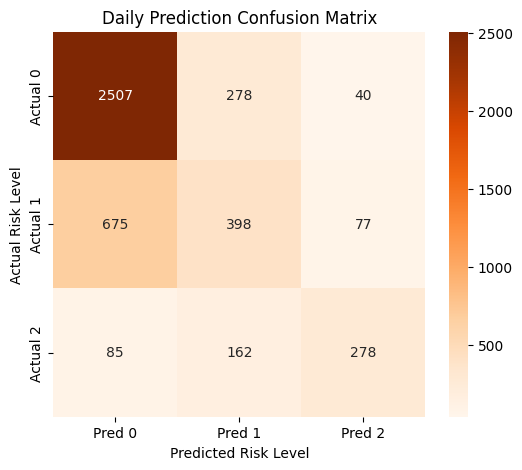

In [46]:
print("\n📊 --- 6. รายงานสรุปผลการประเมินประสิทธิภาพโมเดลบนชุดข้อสอบจริง ---")
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f"🔹 FINAL TEST DAILY MACRO ROC-AUC: {macro_auc:.4f}")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Pre-diabetes (1)', 'Diabetes (2)']))

# พล็อต Confusion Matrix รายวัน
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
plt.title('Daily Prediction Confusion Matrix')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()

# **Model Exploration**

In [51]:
# สร้าง TreeExplainer และคำนวณค่า SHAP

print("🐝 กำลังคำนวณค่า SHAP Values (อาจใช้เวลาสักครู่ตามขนาดข้อมูล)...")
# ใช้ TreeExplainer ซึ่งออกแบบมาให้คำนวณได้เร็วและแม่นยำเป็นพิเศษกับ XGBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

# หมายเหตุ: ใน SHAP เวอร์ชันใหม่ สำหรับโมเดลหลายคลาส
# มิติข้อมูลจะเป็น [จำนวนแถว, จำนวนฟีเจอร์, จำนวนคลาส]
# คลาส 0 = Normal, คลาส 1 = Pre-diabetes, คลาส 2 = Diabetes

🐝 กำลังคำนวณค่า SHAP Values (อาจใช้เวลาสักครู่ตามขนาดข้อมูล)...



📊 1. กำลังพล็อตคะแนนความสำคัญของฟีเจอร์นาฬิกาต่อการพยากรณ์โรคเบาหวาน (Class 2)...


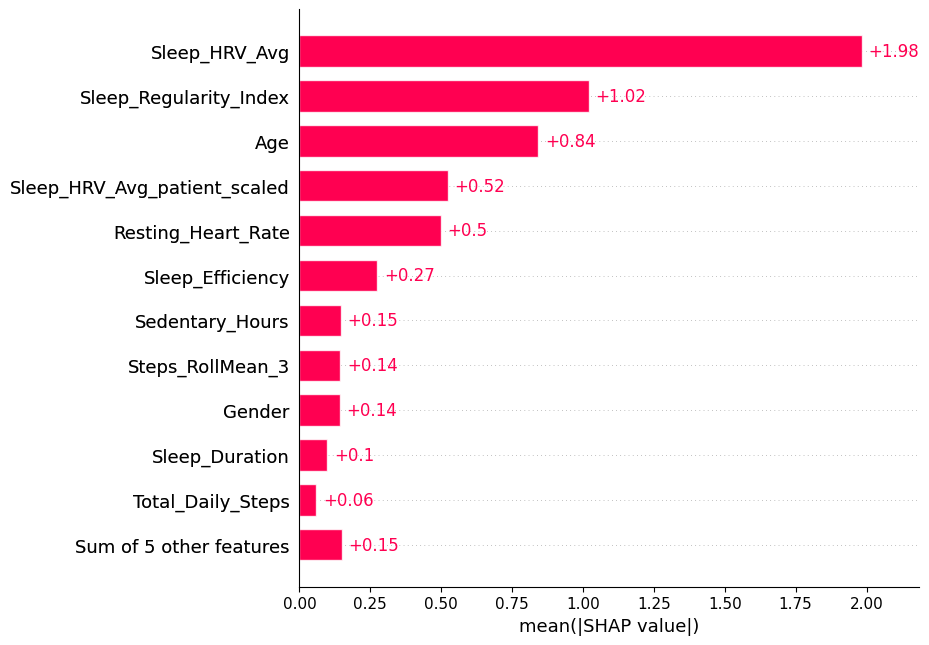

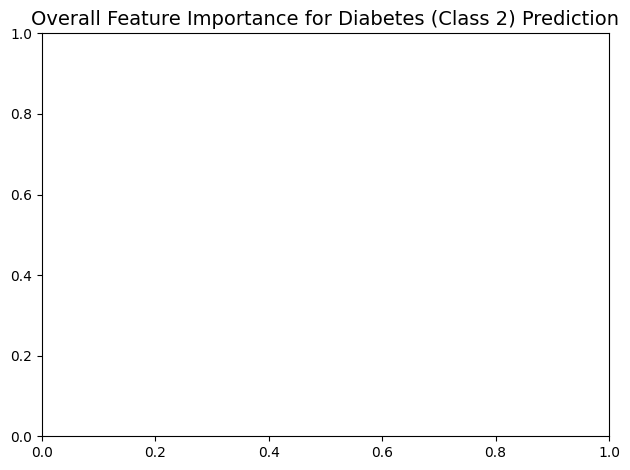

In [52]:
# PLOT 1: Global Feature Importance (Bar Plot)
print("\n📊 1. กำลังพล็อตคะแนนความสำคัญของฟีเจอร์นาฬิกาต่อการพยากรณ์โรคเบาหวาน (Class 2)...")
plt.figure(figsize=(10, 6))
# ดึงข้อมูลเฉพาะสไลซ์ของ Class 2 [:, :, 2] ออกมาพล็อต
shap.plots.bar(shap_values[:, :, 2], max_display=12)
plt.title("Overall Feature Importance for Diabetes (Class 2) Prediction", fontsize=14)
plt.tight_layout()
plt.show()


🐝 2. กำลังพล็อตทิศทางผลกระทบของข้อมูลสรีรวิทยา (Beeswarm Plot - Class 2)...


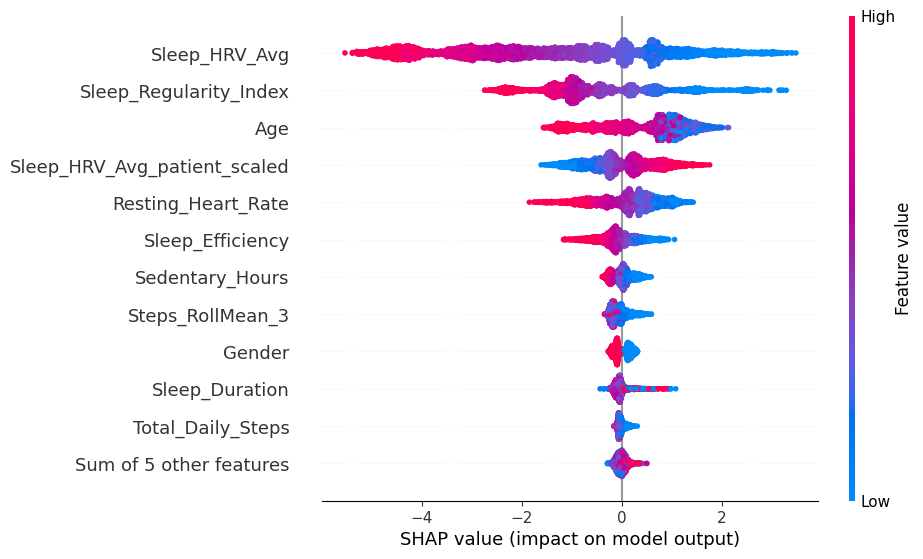

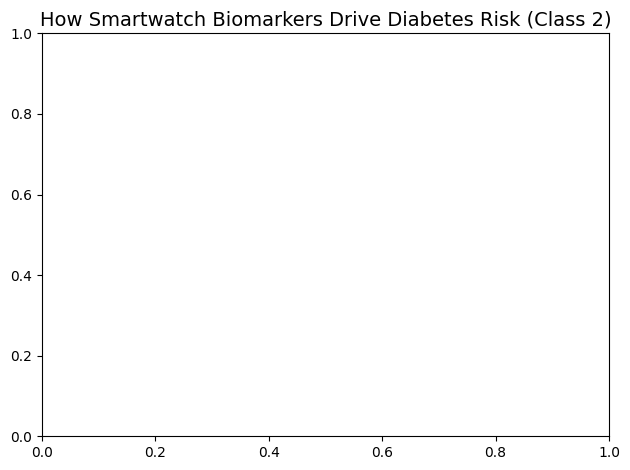

In [53]:
# PLOT 2: Feature Impact Direction (Beeswarm Plot)
print("\n🐝 2. กำลังพล็อตทิศทางผลกระทบของข้อมูลสรีรวิทยา (Beeswarm Plot - Class 2)...")
plt.figure(figsize=(10, 6))
# กราฟนี้จะบอกว่าค่าเซนเซอร์ สูง หรือ ต่ำ ที่ส่งผลให้ความเสี่ยงเบาหวานพุ่งกระฉูด
shap.plots.beeswarm(shap_values[:, :, 2], max_display=12)
plt.title("How Smartwatch Biomarkers Drive Diabetes Risk (Class 2)", fontsize=14)
plt.tight_layout()
plt.show()

# **Export Model**

In [58]:
final_model.save_model("smartwatch_diabetes_model_v2.json")